# 12-security PennyLane QAOA processor with optimization reporting

This notebook is aligned to the 12-security demo workbook and uses:

- PennyLane
- `lightning.qubit` as the simulator
- full-universe QAOA on all 24 binary decision variables
- live optimization reporting
- top-N portfolio output
- optimization history export

## Output sheets
- `Results_Summary`
- `Results_Overview`
- `Results_Portfolios`
- `Solver_Comparison`
- `Classical_Candidates`
- `QAOA_Samples`
- `Optimization_History`


This version uses a **normalized QUBO scaling** for the reward and budget terms so the Hamiltonian is better conditioned for QAOA.

In [1]:
#!pip -q install yfinance openpyxl pandas numpy scipy matplotlib pennylane pennylane-lightning

In [2]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill

from scipy.optimize import minimize

import pennylane as qml

In [3]:
xlsx_path = Path("demo_budget_block_options_12sec.xlsx")

TOP_N_EXPORT = 20
REFRESH_OVERRIDE = None
ENABLE_QAOA = True
QAOA_MAXITER = 60
RANDOM_SEARCH_SAMPLES = 8000
LOCAL_SEARCH_STARTS = 40
RNG_SEED = 42

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

xlsx_path

PosixPath('demo_budget_block_options_12sec.xlsx')

In [4]:
xls = pd.ExcelFile(xlsx_path)

assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
settings = dict(zip(settings_df["Key"], settings_df["Value"]))

display(assets_df.head())
display(settings_df)

,Ticker,Company,Current Price (USD),Price Source Status,12M Return Proxy,Annual Volatility,Mean Daily Return,Std Daily Return,Allowed,Source URL
0,NVDA,NVIDIA,199.430099,Imported via yfinance,0.909054,0.341897,0.002820,0.021538,1,https://pypi.org/project/yfinance/
1,AAPL,Apple,262.440002,Imported via yfinance,0.356791,0.235374,0.001330,0.014827,1,https://pypi.org/project/yfinance/
2,MSFT,Microsoft,416.899994,Imported via yfinance,0.130464,0.244579,0.000610,0.015407,1,https://pypi.org/project/yfinance/
3,AVGO,Broadcom,399.299988,Imported via yfinance,1.305339,0.427863,0.003705,0.026953,1,https://pypi.org/project/yfinance/
4,MU,Micron Technology,457.359985,Imported via yfinance,5.612645,0.589799,0.008267,0.037154,1,https://pypi.org/project/yfinance/


,Key,Value,Description
0,budget_usd,1000000.00,Target total budget
1,risk_free_rate_annual,0.04,Annual risk-free rate used in excess-return re...
2,lambda_budget,50.00,Budget deviation penalty
3,lambda_variance,6.00,Variance contribution weight
4,lambda_exclusive,20.00,Penalty for selecting more than one block opti...
5,top_n_export,20.00,Target number of candidate portfolios to export


In [5]:
refresh_from_settings = False
if "refresh_market_data" in settings:
    refresh_from_settings = bool(int(settings.get("refresh_market_data", 0)))

REFRESH_WITH_YFINANCE = refresh_from_settings if REFRESH_OVERRIDE is None else bool(REFRESH_OVERRIDE)
REFRESH_WITH_YFINANCE

False

In [6]:
if REFRESH_WITH_YFINANCE:
    tickers = assets_df.loc[assets_df["Allowed"] == 1, "Ticker"].dropna().astype(str).tolist()

    prices = yf.download(
        tickers=tickers,
        period="12mo",
        interval="1d",
        auto_adjust=True,
        progress=False,
    )["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices = prices.dropna(how="all").ffill().dropna()
    rets = prices.pct_change().dropna()

    total_return_12m = prices.iloc[-1] / prices.iloc[0] - 1
    ann_vol = rets.std() * np.sqrt(252)
    daily_cov = rets.cov()
    annual_cov = daily_cov * 252

    wb = load_workbook(xlsx_path)
    sh_assets = wb["Assets"]
    sh_returns = wb["Returns"]
    sh_cov = wb["Covariance"]
    sh_acov = wb["AnnualizedCovariance"]
    sh_ph = wb["PriceHistory"]

    for row in sh_ph.iter_rows(min_row=3, max_row=5000, min_col=1, max_col=1 + len(tickers)):
        for cell in row:
            cell.value = None

    for r_idx, dt in enumerate(prices.index, start=3):
        sh_ph.cell(r_idx, 1, dt.to_pydatetime())
        for c_idx, t in enumerate(tickers, start=2):
            sh_ph.cell(r_idx, c_idx, float(prices.loc[dt, t]))

    for idx, t in enumerate(tickers, start=3):
        sh_assets.cell(idx, 3, float(prices[t].iloc[-1]))
        sh_assets.cell(idx, 4, "Refreshed with yfinance")
        sh_assets.cell(idx, 5, float(total_return_12m[t]))
        sh_assets.cell(idx, 6, float(ann_vol[t]))
        sh_assets.cell(idx, 7, float(rets[t].mean()))
        sh_assets.cell(idx, 8, float(rets[t].std()))
        sh_returns.cell(idx, 2, float(total_return_12m[t]))
        sh_returns.cell(idx, 3, float(ann_vol[t]))
        sh_returns.cell(idx, 4, float(rets[t].mean()))
        sh_returns.cell(idx, 5, float(rets[t].std()))
        sh_returns.cell(idx, 6, "Refreshed with yfinance")

    for i, tr in enumerate(tickers, start=3):
        for j, tc in enumerate(tickers, start=2):
            sh_cov.cell(i, j, float(daily_cov.loc[tr, tc]))
            sh_acov.cell(i, j, float(annual_cov.loc[tr, tc]))

    wb.save(xlsx_path)

    xls = pd.ExcelFile(xlsx_path)
    assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
    settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
    settings = dict(zip(settings_df["Key"], settings_df["Value"]))

    print(f"Workbook refreshed and saved to {xlsx_path.resolve()}")

In [7]:
assets_df = assets_df.loc[assets_df["Allowed"] == 1].copy()
assets_df = assets_df.loc[assets_df["Ticker"].notna()].copy()
assets_df["Ticker"] = assets_df["Ticker"].astype(str)

for col in ["Current Price (USD)", "12M Return Proxy", "Annual Volatility"]:
    assets_df[col] = pd.to_numeric(assets_df[col], errors="coerce")

if assets_df["Current Price (USD)"].isna().any():
    bad = assets_df.loc[assets_df["Current Price (USD)"].isna(), "Ticker"].tolist()
    raise ValueError(f"Current Price (USD) missing for {bad}. Run the generator with yfinance first or refresh market data.")

budget_usd = float(settings["budget_usd"])
risk_free = float(settings["risk_free_rate_annual"])
lambda_budget = float(settings["lambda_budget"])
lambda_variance = float(settings["lambda_variance"])
lambda_exclusive = float(settings["lambda_exclusive"])

block_targets = [100000, 150000]

rows = []
for _, row in assets_df.iterrows():
    price = float(row["Current Price (USD)"])
    ticker = str(row["Ticker"])
    company = row["Company"]
    ret = float(row["12M Return Proxy"]) if pd.notna(row["12M Return Proxy"]) else 0.0
    vol = float(row["Annual Volatility"]) if pd.notna(row["Annual Volatility"]) else np.nan

    for target in block_targets:
        shares = max(1, int(round(target / price)))
        approx_cost = shares * price
        label = f"{int(target/1000)}k"
        rows.append({
            "decision_id": f"{ticker}_{label}",
            "Ticker": ticker,
            "Company": company,
            "Block Label": label,
            "Target Block USD": float(target),
            "Shares": int(shares),
            "Approx Cost USD": float(approx_cost),
            "Allowed": 1,
            "Asset Group": ticker,
            "Expected Return Proxy": ret,
            "Annual Volatility": vol,
        })

blocks_df = pd.DataFrame(rows)

annual_cov_df = pd.read_excel(xls, sheet_name="AnnualizedCovariance", header=1)
annual_cov_df = annual_cov_df.rename(columns={annual_cov_df.columns[0]: "Ticker"})
annual_cov_df = annual_cov_df.loc[annual_cov_df["Ticker"].notna()].copy()
annual_cov_df["Ticker"] = annual_cov_df["Ticker"].astype(str)
annual_cov_df = annual_cov_df.set_index("Ticker")

tickers = assets_df["Ticker"].tolist()
Sigma_assets = annual_cov_df.loc[tickers, tickers].to_numpy(dtype=float)
ticker_to_idx = {t: i for i, t in enumerate(tickers)}

decision_ids = blocks_df["decision_id"].tolist()
opt_tickers = blocks_df["Ticker"].tolist()
opt_cost = blocks_df["Approx Cost USD"].astype(float).to_numpy()
opt_ret = blocks_df["Expected Return Proxy"].astype(float).to_numpy()
n = len(decision_ids)

Sigma_opt = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(n):
        Sigma_opt[i, j] = Sigma_assets[ticker_to_idx[opt_tickers[i]], ticker_to_idx[opt_tickers[j]]]

display(blocks_df[["decision_id", "Ticker", "Block Label", "Shares", "Approx Cost USD", "Expected Return Proxy"]].head(24))
print("Number of decision variables:", n)

,decision_id,Ticker,Block Label,Shares,Approx Cost USD,Expected Return Proxy
0,NVDA_100k,NVDA,100k,501,99914.479843,0.909054
1,NVDA_150k,NVDA,150k,752,149971.434814,0.909054
2,AAPL_100k,AAPL,100k,381,99989.640930,0.356791
3,AAPL_150k,AAPL,150k,572,150115.681396,0.356791
4,MSFT_100k,MSFT,100k,240,100055.998535,0.130464
5,MSFT_150k,MSFT,150k,360,150083.997803,0.130464
6,AVGO_100k,AVGO,100k,250,99824.996948,1.305339
7,AVGO_150k,AVGO,150k,376,150136.795410,1.305339
8,MU_100k,MU,100k,219,100161.836792,5.612645
9,MU_150k,MU,150k,328,150014.075195,5.612645


Number of decision variables: 24


In [8]:
def build_qubo_budget_first(opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
                             lambda_budget, lambda_variance, lambda_exclusive, opt_tickers):
    n = len(opt_ret)
    Q = np.zeros((n, n), dtype=float)

    # Normalized scaling
    scaled_cost = opt_cost / budget_usd

    # Normalized reward contribution
    reward = (opt_ret - risk_free) * scaled_cost

    # Reward term
    for i in range(n):
        Q[i, i] += -reward[i]

    # Variance term
    for i in range(n):
        Q[i, i] += lambda_variance * (scaled_cost[i] ** 2) * Sigma_opt[i, i]
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_variance * scaled_cost[i] * scaled_cost[j] * Sigma_opt[i, j]

    # Budget penalty: lambda_budget * (sum_i scaled_cost_i * x_i - 1)^2
    for i in range(n):
        Q[i, i] += lambda_budget * (scaled_cost[i] ** 2 - 2.0 * scaled_cost[i])
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_budget * scaled_cost[i] * scaled_cost[j]
    constant = lambda_budget

    # One-option-per-asset exclusivity
    from collections import defaultdict
    by_ticker = defaultdict(list)
    for idx, t in enumerate(opt_tickers):
        by_ticker[t].append(idx)

    for _, idxs in by_ticker.items():
        for a in range(len(idxs)):
            for b in range(a + 1, len(idxs)):
                i, j = idxs[a], idxs[b]
                Q[min(i, j), max(i, j)] += lambda_exclusive

    return Q, constant, reward

Q, constant, reward = build_qubo_budget_first(
    opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
    lambda_budget, lambda_variance, lambda_exclusive, opt_tickers
)

pd.DataFrame(Q, index=decision_ids, columns=decision_ids).iloc[:10, :10].round(4)

,NVDA_100k,NVDA_150k,AAPL_100k,AAPL_150k,MSFT_100k,MSFT_150k,AVGO_100k,AVGO_150k,MU_100k,MU_150k
NVDA_100k,-9.5721,21.5195,1.0018,1.5040,1.0040,1.5059,1.0079,1.5158,1.0125,1.5165
NVDA_150k,0.0000,-13.9871,1.5037,2.2575,1.5069,2.2604,1.5128,2.2753,1.5198,2.2762
AAPL_100k,0.0000,0.0000,-9.5274,21.5110,1.0016,1.5024,1.0010,1.5055,1.0045,1.5045
AAPL_150k,0.0000,0.0000,0.0000,-13.9249,1.5038,2.2556,1.5028,2.2602,1.5081,2.2587
MSFT_100k,0.0000,0.0000,0.0000,0.0000,-9.5105,21.5125,1.0032,1.5088,1.0052,1.5056
MSFT_150k,0.0000,0.0000,0.0000,0.0000,0.0000,-13.8876,1.5048,2.2632,1.5078,2.2583
AVGO_100k,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-9.5996,21.5317,1.0134,1.5178
AVGO_150k,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-14.0518,1.5242,2.2828
MU_100k,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-10.0518,21.5653
MU_150k,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-14.6652


In [9]:
def qubo_value(bitvec, Q, constant=0.0):
    x = np.asarray(bitvec, dtype=float)
    return float(x @ Q @ x + constant)

def portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    x = np.asarray(bitvec, dtype=float)
    selected_cost = x * opt_cost
    total = float(selected_cost.sum())
    num_selected = int(x.sum())

    if total <= 0:
        return {
            "selected_usd": 0.0,
            "budget_gap": -budget_usd,
            "abs_budget_gap": abs(-budget_usd),
            "num_options": 0,
            "num_distinct_assets": 0,
            "portfolio_return": 0.0,
            "portfolio_vol": 0.0,
            "sharpe_like": np.nan,
            "max_position_usd": 0.0,
        }

    weights = selected_cost / total
    port_ret = float(np.dot(weights, opt_ret))
    port_var = float(weights @ Sigma_opt @ weights)
    port_vol = float(np.sqrt(max(port_var, 0.0)))
    sharpe = np.nan if port_vol == 0 else (port_ret - risk_free) / port_vol
    distinct_assets = len(set([opt_tickers[i] for i, b in enumerate(x) if b > 0.5]))
    max_position = float(selected_cost.max())
    budget_gap = total - budget_usd

    return {
        "selected_usd": total,
        "budget_gap": budget_gap,
        "abs_budget_gap": abs(budget_gap),
        "num_options": num_selected,
        "num_distinct_assets": distinct_assets,
        "portfolio_return": port_ret,
        "portfolio_vol": port_vol,
        "sharpe_like": sharpe,
        "max_position_usd": max_position,
    }

def decode_solution(bitvec, blocks_df):
    bitvec = np.asarray(bitvec, dtype=int)
    cols = ["decision_id", "Ticker", "Company", "Block Label", "Shares", "Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]
    return blocks_df.loc[bitvec == 1, cols].copy().reset_index(drop=True)

def exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    selected = decode_solution(bitvec, blocks_df)
    stats = portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    rows = []
    if selected.empty:
        rows.append({
            "rank": rank, "source": source, "bitstring": bitstring, "Ticker": "", "Company": "", "Block Label": "",
            "Shares": 0, "Approx Cost USD": 0.0, "Expected Return Proxy": 0.0, "Annual Volatility": 0.0,
            "qubo_value": qubo_value(bitvec, Q, constant), **stats
        })
    else:
        for _, r in selected.iterrows():
            rows.append({
                "rank": rank, "source": source, "bitstring": bitstring,
                "Ticker": r["Ticker"], "Company": r["Company"], "Block Label": r["Block Label"],
                "Shares": r["Shares"], "Approx Cost USD": r["Approx Cost USD"],
                "Expected Return Proxy": r["Expected Return Proxy"], "Annual Volatility": r["Annual Volatility"],
                "qubo_value": qubo_value(bitvec, Q, constant), **stats
            })
    return rows

def is_feasible(bitvec, opt_tickers):
    chosen = [opt_tickers[i] for i, b in enumerate(bitvec) if b > 0.5]
    return len(chosen) == len(set(chosen))

def sort_candidates(df):
    sort_cols = [c for c in ["sharpe_like", "abs_budget_gap", "qubo_value", "probability"] if c in df.columns]
    ascending = [(False if c in ["sharpe_like", "probability"] else True) for c in sort_cols]
    return df.sort_values(sort_cols, ascending=ascending, na_position="last").reset_index(drop=True)

In [10]:
def random_feasible_solution(n, opt_tickers):
    x = np.zeros(n, dtype=int)
    used = set()
    order = np.random.permutation(n)
    for i in order:
        t = opt_tickers[i]
        if t not in used and np.random.rand() < 0.5:
            x[i] = 1
            used.add(t)
    return x

def greedy_repair_and_improve(x, Q, constant, opt_tickers):
    x = x.copy()
    by_ticker = {}
    for i, t in enumerate(opt_tickers):
        if x[i] == 1:
            by_ticker.setdefault(t, []).append(i)
    for _, idxs in by_ticker.items():
        if len(idxs) > 1:
            vals = []
            for idx in idxs:
                test = x.copy()
                for j in idxs:
                    test[j] = 0
                test[idx] = 1
                vals.append((qubo_value(test, Q, constant), idx))
            best_idx = min(vals)[1]
            for j in idxs:
                x[j] = 1 if j == best_idx else 0

    improved = True
    while improved:
        improved = False
        current_val = qubo_value(x, Q, constant)
        for i in range(len(x)):
            y = x.copy()
            y[i] = 1 - y[i]
            if not is_feasible(y, opt_tickers):
                continue
            y_val = qubo_value(y, Q, constant)
            if y_val < current_val - 1e-9:
                x = y
                current_val = y_val
                improved = True
        if not improved:
            for i in range(len(x)):
                for j in range(len(x)):
                    if i == j:
                        continue
                    if opt_tickers[i] != opt_tickers[j]:
                        continue
                    if x[i] == 1 and x[j] == 0:
                        y = x.copy()
                        y[i] = 0
                        y[j] = 1
                        y_val = qubo_value(y, Q, constant)
                        if y_val < current_val - 1e-9:
                            x = y
                            current_val = y_val
                            improved = True
                            break
                if improved:
                    break
    return x

candidate_dict = {}
for _ in range(RANDOM_SEARCH_SAMPLES):
    x = random_feasible_solution(n, opt_tickers)
    x = greedy_repair_and_improve(x, Q, constant, opt_tickers)
    bitstring = "".join(map(str, x.astype(int)))
    stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    candidate_dict[bitstring] = {"bitstring": bitstring, "source": "classical_heuristic", "probability": np.nan, "qubo_value": qubo_value(x, Q, constant), **stats}

for start_idx in range(min(n, LOCAL_SEARCH_STARTS)):
    x = np.zeros(n, dtype=int)
    x[start_idx] = 1
    x = greedy_repair_and_improve(x, Q, constant, opt_tickers)
    bitstring = "".join(map(str, x.astype(int)))
    stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    candidate_dict[bitstring] = {"bitstring": bitstring, "source": "classical_heuristic", "probability": np.nan, "qubo_value": qubo_value(x, Q, constant), **stats}

classical_results = sort_candidates(pd.DataFrame(candidate_dict.values()))
display(classical_results.head(20))
print("Classical candidate count:", len(classical_results))

,bitstring,source,probability,qubo_value,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,000101100100100110100000,classical_heuristic,NaN,-1.501249,1.000163e+06,163.425659,163.425659,8,8,2.022326,0.283208,6.999530,150115.681396
1,001001000100100110011000,classical_heuristic,NaN,-1.527775,1.000256e+06,255.537086,255.537086,8,8,2.087209,0.294304,6.956108,150083.997803
2,001010100100010110010000,classical_heuristic,NaN,-1.545730,9.997373e+05,-262.697289,262.697289,8,8,2.128909,0.300808,6.944333,150014.075195
3,001001000100100101101000,classical_heuristic,NaN,-1.573167,1.000321e+06,320.939117,320.939117,8,8,2.186278,0.309146,6.942608,150083.997803
4,001010100100010101100000,classical_heuristic,NaN,-1.590663,9.998027e+05,-197.295258,197.295258,8,8,2.228026,0.315480,6.935551,150014.075195
5,000110100100000110011000,classical_heuristic,NaN,-1.491074,1.000044e+06,43.931190,43.931190,8,8,2.020841,0.285719,6.932834,150115.681396
6,000110000100100101100010,classical_heuristic,NaN,-1.570495,1.001120e+06,1120.361816,1120.361816,8,8,2.183161,0.309224,6.930768,150115.681396
7,101001000100100101100000,classical_heuristic,NaN,-1.524302,1.000125e+06,124.969894,124.969894,8,8,2.090704,0.296233,6.922596,150083.997803
8,001001010100100110100000,classical_heuristic,NaN,-1.514005,1.000349e+06,349.183655,349.183655,8,8,2.069723,0.293275,6.920895,150136.795410
9,001000100100100101011000,classical_heuristic,NaN,-1.628919,9.999946e+05,-5.361961,5.361961,8,8,2.324151,0.330461,6.912017,150014.075195


Classical candidate count: 2781


In [11]:
samples_df = pd.DataFrame(columns=[
    "bitstring", "source", "probability", "qubo_value", "selected_usd", "budget_gap",
    "abs_budget_gap", "num_options", "num_distinct_assets", "portfolio_return",
    "portfolio_vol", "sharpe_like", "max_position_usd"
])

history_df = pd.DataFrame(columns=["iteration", "gamma", "beta", "energy", "best_energy", "elapsed_sec"])
best_gamma, best_beta = np.nan, np.nan

if ENABLE_QAOA:
    def qubo_to_ising(Q, constant=0.0):
        n = Q.shape[0]
        h = np.zeros(n, dtype=float)
        J = {}
        offset = float(constant)
        for i in range(n):
            qii = Q[i, i]
            offset += qii / 2
            h[i] += -qii / 2
        for i in range(n):
            for j in range(i + 1, n):
                qij = Q[i, j]
                if abs(qij) > 1e-12:
                    offset += qij / 4
                    h[i] += -qij / 4
                    h[j] += -qij / 4
                    J[(i, j)] = qij / 4
        return h, J, offset

    h, J, ising_offset = qubo_to_ising(Q, constant)

    coeffs = []
    ops = []
    for i, coeff in enumerate(h):
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i))
    for (i, j), coeff in J.items():
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    if not coeffs:
        coeffs = [0.0]
        ops = [qml.Identity(0)]

    H = qml.Hamiltonian(coeffs, ops)
    dev = qml.device("lightning.qubit", wires=n)

    @qml.qnode(dev, interface="autograd")
    def qaoa_energy(params):
        gamma, beta = params
        for w in range(n):
            qml.Hadamard(wires=w)
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                qml.RZ(2 * gamma * coeff, wires=i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-12:
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * gamma * coeff, wires=j)
                qml.CNOT(wires=[i, j])
        for w in range(n):
            qml.RX(2 * beta, wires=w)
        return qml.expval(H)

    @qml.qnode(dev, interface="autograd")
    def qaoa_probs(params):
        gamma, beta = params
        for w in range(n):
            qml.Hadamard(wires=w)
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                qml.RZ(2 * gamma * coeff, wires=i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-12:
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * gamma * coeff, wires=j)
                qml.CNOT(wires=[i, j])
        for w in range(n):
            qml.RX(2 * beta, wires=w)
        return qml.probs(wires=range(n))

    progress_rows = []
    start_time = time.time()

    def objective_logged(x):
        energy = float(qaoa_energy(x))
        elapsed = time.time() - start_time
        current_best = min([energy] + [r["energy"] for r in progress_rows]) if progress_rows else energy
        progress_rows.append({
            "iteration": len(progress_rows) + 1,
            "gamma": float(x[0]),
            "beta": float(x[1]),
            "energy": energy,
            "best_energy": current_best,
            "elapsed_sec": elapsed,
        })
        print(f"iter={len(progress_rows):>3}  gamma={x[0]: .5f}  beta={x[1]: .5f}  energy={energy: .6f}  best={current_best: .6f}  elapsed={elapsed: .1f}s")
        return energy

    res = minimize(objective_logged, x0=np.array([0.4, 0.6]), method="COBYLA", options={"maxiter": QAOA_MAXITER})
    best_gamma, best_beta = res.x
    history_df = pd.DataFrame(progress_rows)

    probs = np.array(qaoa_probs(np.array([best_gamma, best_beta])))

    q_rows = []
    for idx, prob in enumerate(probs):
        if prob <= 0:
            continue
        bitstring = format(idx, f"0{n}b")[::-1]
        bits = np.array(list(map(int, bitstring)), dtype=int)
        if not is_feasible(bits, opt_tickers):
            continue
        stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        q_rows.append({
            "bitstring": "".join(map(str, bits.astype(int))),
            "source": "qaoa_full_pennylane",
            "probability": float(prob),
            "qubo_value": qubo_value(bits, Q, constant),
            **stats
        })

    samples_df = sort_candidates(pd.DataFrame(q_rows))
    print("Full PennyLane QAOA completed.")
    display(history_df.head(20))
    display(samples_df.head(20))
else:
    print("QAOA disabled.")

iter=  1  gamma= 0.40000  beta= 0.60000  energy= 12.171926  best= 12.171926  elapsed= 17.9s
iter=  2  gamma= 1.40000  beta= 0.60000  energy=-1.964763  best=-1.964763  elapsed= 35.6s
iter=  3  gamma= 1.40000  beta= 1.60000  energy=-0.007604  best=-1.964763  elapsed= 53.4s
iter=  4  gamma= 2.39055  beta= 0.46286  energy= 2.072957  best=-1.964763  elapsed= 71.2s
iter=  5  gamma= 0.94408  beta= 0.39474  energy= 5.556038  best=-1.964763  elapsed= 88.9s
iter=  6  gamma= 1.64843  beta= 0.57202  energy= 9.434553  best=-1.964763  elapsed= 106.5s
iter=  7  gamma= 1.40560  beta= 0.64969  energy=-2.236575  best=-2.236575  elapsed= 124.2s
iter=  8  gamma= 1.30825  beta= 0.67256  energy= 11.869615  best=-2.236575  elapsed= 141.8s
iter=  9  gamma= 1.50532  beta= 0.64228  energy= 13.120047  best=-2.236575  elapsed= 159.5s
iter= 10  gamma= 1.35614  beta= 0.65703  energy= 2.874091  best=-2.236575  elapsed= 177.1s
iter= 11  gamma= 1.43055  beta= 0.64821  energy=-1.227211  best=-2.236575  elapsed= 194.7s


,iteration,gamma,beta,energy,best_energy,elapsed_sec
0,1,0.400000,0.600000,12.171926,12.171926,17.913841
1,2,1.400000,0.600000,-1.964763,-1.964763,35.612796
2,3,1.400000,1.600000,-0.007604,-1.964763,53.416442
3,4,2.390552,0.462863,2.072957,-1.964763,71.210597
4,5,0.944075,0.394737,5.556038,-1.964763,88.892239
5,6,1.648429,0.572019,9.434553,-1.964763,106.547356
6,7,1.405596,0.649686,-2.236575,-2.236575,124.195991
7,8,1.308248,0.672563,11.869615,-2.236575,141.838981
8,9,1.505322,0.642284,13.120047,-2.236575,159.470076
9,10,1.356139,0.657033,2.874091,-2.236575,177.075920


,bitstring,source,probability,qubo_value,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,000000000100000000000000,qaoa_full_pennylane,1.150990e-06,35.334799,150014.075195,-849985.924805,849985.924805,1,1,5.612645,0.589799,9.448388,150014.075195
1,000000001000000000000000,qaoa_full_pennylane,7.065992e-07,39.948209,100161.836792,-899838.163208,899838.163208,1,1,5.612645,0.589799,9.448388,100161.836792
2,001000000100000000000000,qaoa_full_pennylane,6.653297e-08,27.311839,250003.716125,-749996.283875,749996.283875,2,2,3.510553,0.382158,9.081468,150014.075195
3,000000000100000000100000,qaoa_full_pennylane,5.339024e-08,27.294163,250046.194946,-749953.805054,749953.805054,2,2,3.579066,0.391702,9.035102,150014.075195
4,000000000100001000000000,qaoa_full_pennylane,5.126224e-07,27.091005,249900.229797,-750099.770203,750099.770203,2,2,4.607210,0.516265,8.846639,150014.075195
5,000010000100000000000000,qaoa_full_pennylane,6.485005e-08,27.329851,250070.073730,-749929.926270,749929.926270,2,2,3.419160,0.383326,8.815367,150014.075195
6,001000001000000000000000,qaoa_full_pennylane,3.356970e-07,31.425291,200151.477722,-799848.522278,799848.522278,2,2,2.986979,0.336707,8.752356,100161.836792
7,000100000100000000000000,qaoa_full_pennylane,7.086143e-08,23.668566,300129.756592,-699870.243408,699870.243408,2,2,2.983829,0.336446,8.749769,150115.681396
8,000000001000000000100000,qaoa_full_pennylane,2.487607e-07,31.406636,200193.956543,-799806.043457,799806.043457,2,2,3.072665,0.348900,8.692071,100161.836792
9,000000000100000000010000,qaoa_full_pennylane,4.584376e-08,23.657799,299978.894722,-700021.105278,700021.105278,2,2,3.071435,0.348801,8.691005,150014.075195


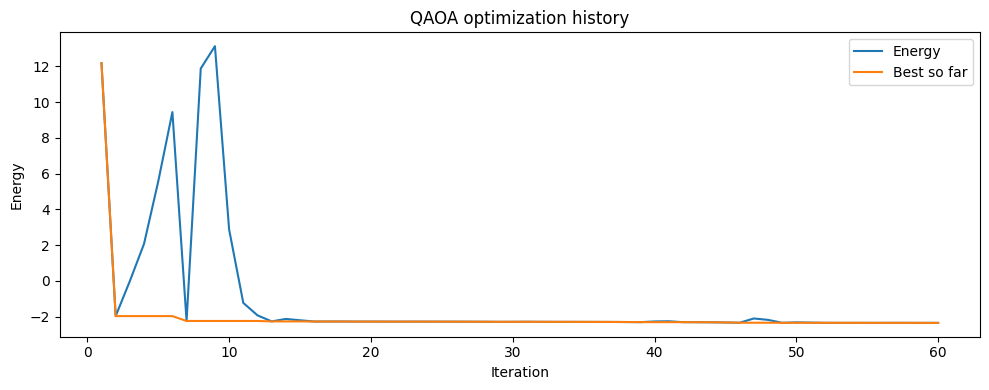

In [12]:
if len(history_df):
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["iteration"], history_df["energy"], label="Energy")
    plt.plot(history_df["iteration"], history_df["best_energy"], label="Best so far")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("QAOA optimization history")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
classical_pool = classical_results.head(300).copy()
qaoa_pool = samples_df.head(500).copy() if len(samples_df) else samples_df.copy()

combined = pd.concat([
    classical_pool[["bitstring", "source", "probability", "qubo_value", "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets", "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"]],
    qaoa_pool[["bitstring", "source", "probability", "qubo_value", "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets", "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"]],
], ignore_index=True)

combined = sort_candidates(combined).drop_duplicates(subset=["bitstring"], keep="first").reset_index(drop=True)
overview_df = sort_candidates(combined).head(TOP_N_EXPORT).copy()
overview_df.insert(0, "rank", range(1, len(overview_df) + 1))
display(overview_df)

,rank,bitstring,source,probability,qubo_value,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,000000000100000000000000,qaoa_full_pennylane,1.150990e-06,35.334799,150014.075195,-849985.924805,849985.924805,1,1,5.612645,0.589799,9.448388,150014.075195
1,2,000000001000000000000000,qaoa_full_pennylane,7.065992e-07,39.948209,100161.836792,-899838.163208,899838.163208,1,1,5.612645,0.589799,9.448388,100161.836792
2,3,001000000100000000000000,qaoa_full_pennylane,6.653297e-08,27.311839,250003.716125,-749996.283875,749996.283875,2,2,3.510553,0.382158,9.081468,150014.075195
3,4,000000000100000000100000,qaoa_full_pennylane,5.339024e-08,27.294163,250046.194946,-749953.805054,749953.805054,2,2,3.579066,0.391702,9.035102,150014.075195
4,5,000000000100001000000000,qaoa_full_pennylane,5.126224e-07,27.091005,249900.229797,-750099.770203,750099.770203,2,2,4.607210,0.516265,8.846639,150014.075195
5,6,000010000100000000000000,qaoa_full_pennylane,6.485005e-08,27.329851,250070.073730,-749929.926270,749929.926270,2,2,3.419160,0.383326,8.815367,150014.075195
6,7,001000001000000000000000,qaoa_full_pennylane,3.356970e-07,31.425291,200151.477722,-799848.522278,799848.522278,2,2,2.986979,0.336707,8.752356,100161.836792
7,8,000100000100000000000000,qaoa_full_pennylane,7.086143e-08,23.668566,300129.756592,-699870.243408,699870.243408,2,2,2.983829,0.336446,8.749769,150115.681396
8,9,000000001000000000100000,qaoa_full_pennylane,2.487607e-07,31.406636,200193.956543,-799806.043457,799806.043457,2,2,3.072665,0.348900,8.692071,100161.836792
9,10,000000000100000000010000,qaoa_full_pennylane,4.584376e-08,23.657799,299978.894722,-700021.105278,700021.105278,2,2,3.071435,0.348801,8.691005,150014.075195


In [14]:
exploded_rows = []
for _, row in overview_df.iterrows():
    bitstring = row["bitstring"]
    source = row["source"]
    rank = int(row["rank"])
    bitvec = np.array(list(map(int, bitstring)), dtype=int)
    exploded_rows.extend(
        exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    )

portfolios_df = pd.DataFrame(exploded_rows)
display(portfolios_df.head(40))

,rank,source,bitstring,Ticker,Company,Block Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,qubo_value,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,qaoa_full_pennylane,000000000100000000000000,MU,Micron Technology,150k,328,150014.075195,5.612645,0.589799,35.334799,150014.075195,-849985.924805,849985.924805,1,1,5.612645,0.589799,9.448388,150014.075195
1,2,qaoa_full_pennylane,000000001000000000000000,MU,Micron Technology,100k,219,100161.836792,5.612645,0.589799,39.948209,100161.836792,-899838.163208,899838.163208,1,1,5.612645,0.589799,9.448388,100161.836792
2,3,qaoa_full_pennylane,001000000100000000000000,AAPL,Apple,100k,381,99989.640930,0.356791,0.235374,27.311839,250003.716125,-749996.283875,749996.283875,2,2,3.510553,0.382158,9.081468,150014.075195
3,3,qaoa_full_pennylane,001000000100000000000000,MU,Micron Technology,150k,328,150014.075195,5.612645,0.589799,27.311839,250003.716125,-749996.283875,749996.283875,2,2,3.510553,0.382158,9.081468,150014.075195
4,4,qaoa_full_pennylane,000000000100000000100000,MU,Micron Technology,150k,328,150014.075195,5.612645,0.589799,27.294163,250046.194946,-749953.805054,749953.805054,2,2,3.579066,0.391702,9.035102,150014.075195
5,4,qaoa_full_pennylane,000000000100000000100000,CSCO,Cisco,100k,1200,100032.119751,0.529391,0.251681,27.294163,250046.194946,-749953.805054,749953.805054,2,2,3.579066,0.391702,9.035102,150014.075195
6,5,qaoa_full_pennylane,000000000100001000000000,MU,Micron Technology,150k,328,150014.075195,5.612645,0.589799,27.091005,249900.229797,-750099.770203,750099.770203,2,2,4.607210,0.516265,8.846639,150014.075195
7,5,qaoa_full_pennylane,000000000100001000000000,LRCX,Lam Research,100k,377,99886.154602,3.097196,0.487376,27.091005,249900.229797,-750099.770203,750099.770203,2,2,4.607210,0.516265,8.846639,150014.075195
8,6,qaoa_full_pennylane,000010000100000000000000,MSFT,Microsoft,100k,240,100055.998535,0.130464,0.244579,27.329851,250070.073730,-749929.926270,749929.926270,2,2,3.419160,0.383326,8.815367,150014.075195
9,6,qaoa_full_pennylane,000010000100000000000000,MU,Micron Technology,150k,328,150014.075195,5.612645,0.589799,27.329851,250070.073730,-749929.926270,749929.926270,2,2,3.419160,0.383326,8.815367,150014.075195


In [15]:
best_classical = sort_candidates(classical_results).head(1).copy()
solver_frames = [best_classical.assign(solver="Classical Heuristic")]

if len(samples_df):
    best_qaoa = sort_candidates(samples_df).head(1).copy()
    solver_frames.append(best_qaoa.assign(solver="Full QAOA PennyLane"))

solver_comparison_df = pd.concat(solver_frames, ignore_index=True)
solver_comparison_df = solver_comparison_df[[
    "solver", "bitstring", "qubo_value", "selected_usd", "budget_gap", "abs_budget_gap",
    "num_options", "num_distinct_assets", "portfolio_return", "portfolio_vol",
    "sharpe_like", "max_position_usd"
]]

display(solver_comparison_df)

,solver,bitstring,qubo_value,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,Classical Heuristic,000101100100100110100000,-1.501249,1.000163e+06,163.425659,163.425659,8,8,2.022326,0.283208,6.999530,150115.681396
1,Full QAOA PennyLane,000000000100000000000000,35.334799,1.500141e+05,-849985.924805,849985.924805,1,1,5.612645,0.589799,9.448388,150014.075195


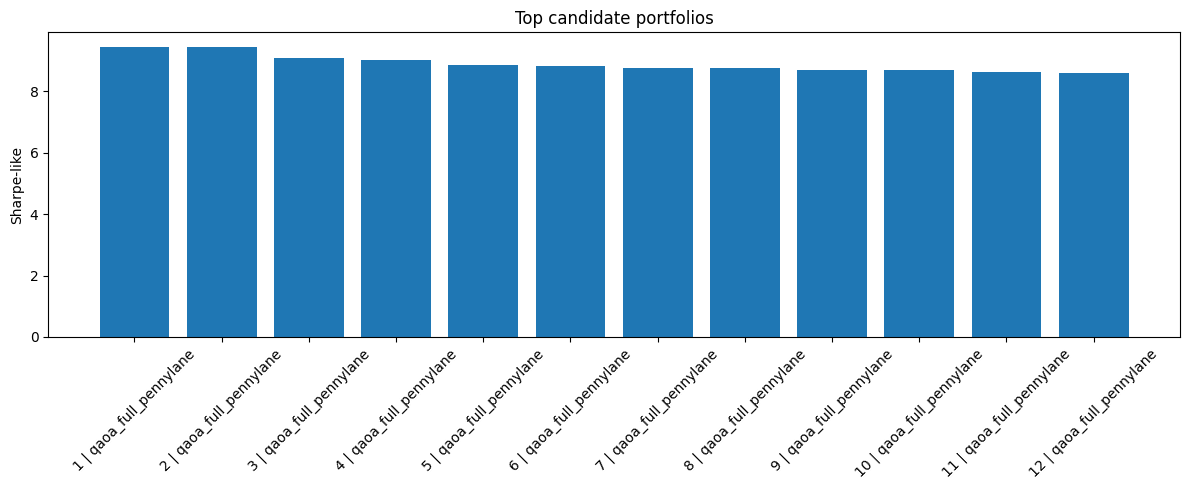

In [16]:
top_plot = overview_df.head(12).copy()
labels = top_plot["rank"].astype(str) + " | " + top_plot["source"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(labels, top_plot["sharpe_like"])
plt.xticks(rotation=45)
plt.ylabel("Sharpe-like")
plt.title("Top candidate portfolios")
plt.tight_layout()
plt.show()

In [17]:
def write_df(ws, df, dark_fill, white_bold):
    for j, col in enumerate(df.columns, start=1):
        ws.cell(1, j, col)
        ws.cell(1, j).fill = dark_fill
        ws.cell(1, j).font = white_bold
    for i, row in enumerate(df.itertuples(index=False), start=2):
        for j, val in enumerate(row, start=1):
            ws.cell(i, j, val)

def write_results(xlsx_path, overview_df, portfolios_df, solver_comparison_df, classical_results, samples_df, history_df, best_gamma, best_beta):
    wb = load_workbook(xlsx_path)

    for name in ["Results_Summary", "Results_Overview", "Results_Portfolios", "QAOA_Samples", "Classical_Candidates", "Solver_Comparison", "Optimization_History"]:
        if name in wb.sheetnames:
            wb.remove(wb[name])

    dark = PatternFill("solid", fgColor="1F4E78")
    white_bold = Font(color="FFFFFF", bold=True)

    summary_ws = wb.create_sheet("Results_Summary")
    summary_ws["A1"] = "Results summary"
    summary_ws["A1"].fill = dark
    summary_ws["A1"].font = white_bold

    summary_items = [
        ("Top-N exported", int(len(overview_df))),
        ("Classical candidate count", int(len(classical_results))),
        ("QAOA candidate count", int(len(samples_df))),
        ("QAOA gamma", float(best_gamma) if pd.notna(best_gamma) else None),
        ("QAOA beta", float(best_beta) if pd.notna(best_beta) else None),
        ("Best overview Sharpe-like", float(overview_df["sharpe_like"].max()) if len(overview_df) else None),
        ("Best overview invested USD", float(overview_df.iloc[0]["selected_usd"]) if len(overview_df) else None),
        ("Best overview abs budget gap", float(overview_df.iloc[0]["abs_budget_gap"]) if len(overview_df) else None),
        ("Optimization iterations", int(len(history_df))),
    ]
    for i, (label, value) in enumerate(summary_items, start=2):
        summary_ws.cell(i, 1, label)
        summary_ws.cell(i, 2, value)

    overview_ws = wb.create_sheet("Results_Overview")
    write_df(overview_ws, overview_df, dark, white_bold)

    portfolios_ws = wb.create_sheet("Results_Portfolios")
    write_df(portfolios_ws, portfolios_df, dark, white_bold)

    qaoa_ws = wb.create_sheet("QAOA_Samples")
    write_df(qaoa_ws, samples_df.head(500), dark, white_bold)

    classical_ws = wb.create_sheet("Classical_Candidates")
    write_df(classical_ws, classical_results.head(500), dark, white_bold)

    solver_ws = wb.create_sheet("Solver_Comparison")
    write_df(solver_ws, solver_comparison_df, dark, white_bold)

    hist_ws = wb.create_sheet("Optimization_History")
    write_df(hist_ws, history_df, dark, white_bold)

    out_path = xlsx_path.with_name(xlsx_path.stem + "_pennylane_topN.xlsx")
    wb.save(out_path)
    return out_path

out_path = write_results(
    xlsx_path=xlsx_path,
    overview_df=overview_df,
    portfolios_df=portfolios_df,
    solver_comparison_df=solver_comparison_df,
    classical_results=classical_results,
    samples_df=samples_df,
    history_df=history_df,
    best_gamma=best_gamma,
    best_beta=best_beta,
)

print(f"Saved workbook with results to: {out_path.resolve()}")

Saved workbook with results to: /Users/danielhug/code/qubit-lab/QAOA-Optimizer/demo_budget_block_options_12sec_pennylane_topN.xlsx
